# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와 사용하는 것
* data_augmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈, 기존 이미지 데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

In [33]:
image = load_img('./catanddog/bird.jpg')
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

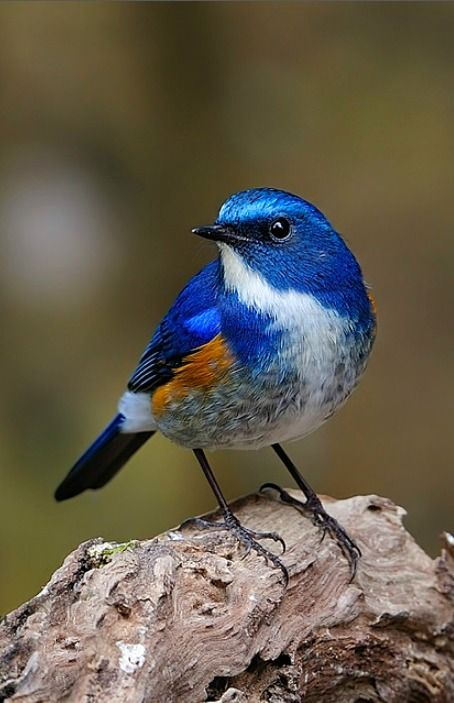

In [21]:
image

# Image Augmentation(이미지 증폭)

In [34]:
# 하이퍼파라미터는 경험적으로
imggen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'    
            )

차원 늘리기

In [29]:
image_array.reshape((1,) + image_array.shape).shape

(1, 703, 454, 3)

In [36]:
image_array = image_array.reshape((1,) + image_array.shape)

In [37]:
image_array.shape

(1, 703, 454, 3)

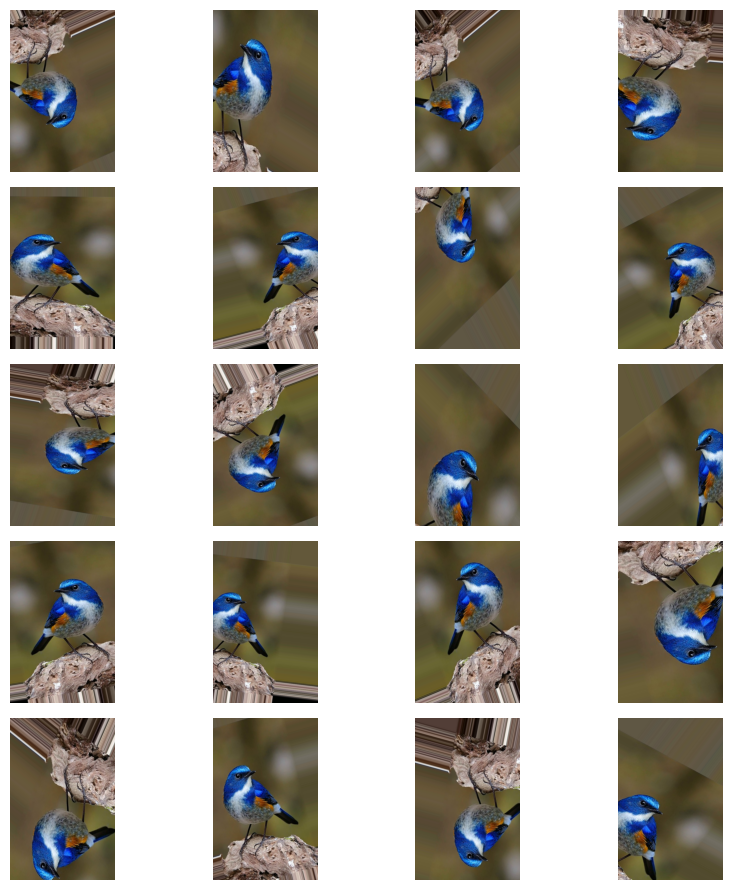

In [38]:
fig, axes = plt.subplots(5,4,figsize=(9,9))
axes = axes.ravel() # 펼치기

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])  # 이미지 객체로 반환
    axes[i].imshow(augmented_image)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류 모델 만들기
* 미니배치경사하강법
    1) 연산적으로 빠름
    2) 학습이 더 안정적 - 노이즈가 줄어듦

In [39]:
# 데이터 로드
train_dir = './catanddog/train/'
valid_dir = './catanddog/validation/'
batch_size = 16 # 한 번에 불러오는 이미지의 개수(미니배치 크기), 분석 모델에 따라서 16(큼)~32(작음) 사이로 설정
image_size = (224,224) # 모델의 입력 크기에 맞춤 - 단위는 픽셀

In [40]:
# 1) 훈련용 이미지 증강기 설정
train_aug = ImageDataGenerator(
    rescale=1./255,          # 픽셀 값을 0~1 사이로 정규화
    rotation_range=40,       # 이미지를 -40°~+40° 사이로 랜덤 회전
    width_shift_range=0.3,   # 너비 기준으로 전체 폭의 30% 내에서 랜덤 이동
    height_shift_range=0.2,  # 높이 기준으로 전체 높이의 20% 내에서 랜덤 이동
    shear_range=0.6,         # 전단(shear) 변환 강도 지정
    zoom_range=0.3,          # 70%~130% 사이로 랜덤 확대/축소
    fill_mode='nearest'      # 변형 후 빈 영역을 인접 픽셀 값으로 채움
)

# 2) 검증용 이미지는 오직 정규화만
valid_aug = ImageDataGenerator(
    rescale=1./255           # 동일하게 0~1 사이로 정규화
)

# 3) 디스크의 폴더 구조에서 이미지와 레이블을 함께 불러오는 제너레이터 생성
train_gen = train_aug.flow_from_directory(
    directory=train_dir,         # 훈련 이미지가 담긴 최상위 폴더 경로
    target_size=image_size,      # (높이, 너비) = (예: 150,150) 픽셀로 모든 이미지를 리사이즈
    batch_size=batch_size,       # 한 번에 가져올 샘플 수
    class_mode='categorical',    # 다중 클래스(one-hot) 레이블 생성
    shuffle=True,                # 매 epoch마다 섞어서 배치 생성
    seed=42                      # 섞는 순서를 고정하여 재현성 유지
)

valid_gen = valid_aug.flow_from_directory(
    directory=valid_dir,         # 검증 이미지가 담긴 폴더
    target_size=image_size,      # 동일한 크기로 리사이즈
    batch_size=batch_size,       # 동일한 배치 크기
    class_mode='categorical',    # 다중 클래스(one-hot)
    shuffle=True,                # 검증도 섞어서 배치 생성 (필요 시 False로 변경 가능)
    seed=42
)

# 4) 하나의 배치(이미지  X_batch, 레이블 y_batch) 가져오기
X_batch, y_batch = next(train_gen)

print(X_batch.shape)       # (batch_size, height, width, channels)
print(y_batch.shape)       # (batch_size, num_classes)
print(train_gen.class_indices)  # 폴더 이름 ↔ 인덱스 매핑(dict)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류


In [42]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [44]:
cnn_model = Sequential()

# 합성곱층
cnn_model.add(Input(shape=(224,224,3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

# 밀집층
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(2, activation='softmax'))  # 원핫인코딩이기 때문 -> 그냥 0/1이면 시그모이드

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
import tensorflow as tf

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1747709074.383677     104 service.cc:146] XLA service 0x7f6198004b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747709074.383735     104 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-20 02:44:34.447915: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-20 02:44:34.788454: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
E0000 00:00:1747709078.261784     104 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747709078.479892     104 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/139 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.5625 - loss: 0.6871  

I0000 00:00:1747709082.421135     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 65/139 ━━━━━━━━━━━━━━━━━━━━ 25s 344ms/step - accuracy: 0.5028 - loss: 0.7003

E0000 00:00:1747709107.333979     104 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747709107.561068     104 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.4988 - loss: 0.6978
Epoch 1: val_loss improved from inf to 0.69007, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 78s 489ms/step - accuracy: 0.4988 - loss: 0.6978 - val_accuracy: 0.6224 - val_loss: 0.6901
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5178 - loss: 0.6917
Epoch 2: val_loss improved from 0.69007 to 0.67501, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 246ms/step - accuracy: 0.5179 - loss: 0.6917 - val_accuracy: 0.6020 - val_loss: 0.6750
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5623 - loss: 0.6873
Epoch 3: val_loss did not improve from 0.67501
139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 250ms/step - accuracy: 0.5622 - loss: 0.6873 - val_accuracy: 0.5306 - val_loss: 0.6799
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5549 - loss: 0.6845
Epoch 4: val_loss improved from 0.67501 to 0.65474, saving model 

Epoch 25/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6756 - loss: 0.5927
Epoch 25: val_loss did not improve from 0.53920
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 298ms/step - accuracy: 0.6756 - loss: 0.5927 - val_accuracy: 0.7143 - val_loss: 0.5479
Epoch 26/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.7024 - loss: 0.5817
Epoch 26: val_loss did not improve from 0.53920
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 302ms/step - accuracy: 0.7023 - loss: 0.5817 - val_accuracy: 0.6735 - val_loss: 0.5878
Epoch 27/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6992 - loss: 0.5843
Epoch 27: val_loss did not improve from 0.53920
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 304ms/step - accuracy: 0.6992 - loss: 0.5842 - val_accuracy: 0.6939 - val_loss: 0.5432
Epoch 28/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6719 - loss: 0.5896
Epoch 28: val_loss did not improve from 0.53920
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 314ms/step - accuracy: 0.6719 - loss: 0.5896 - val_accu

Epoch 50/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.7316 - loss: 0.5416
Epoch 50: val_loss did not improve from 0.50780
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 302ms/step - accuracy: 0.7315 - loss: 0.5416 - val_accuracy: 0.6837 - val_loss: 0.5467
Epoch 51/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7401 - loss: 0.5243
Epoch 51: val_loss did not improve from 0.50780
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 303ms/step - accuracy: 0.7401 - loss: 0.5243 - val_accuracy: 0.6837 - val_loss: 0.5326
Epoch 52/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.7475 - loss: 0.5208
Epoch 52: val_loss did not improve from 0.50780
139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 308ms/step - accuracy: 0.7474 - loss: 0.5208 - val_accuracy: 0.6939 - val_loss: 0.5554
Epoch 53/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7317 - loss: 0.5376
Epoch 53: val_loss did not improve from 0.50780
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 317ms/step - accuracy: 0.7318 - loss: 0.5376 - val_accu

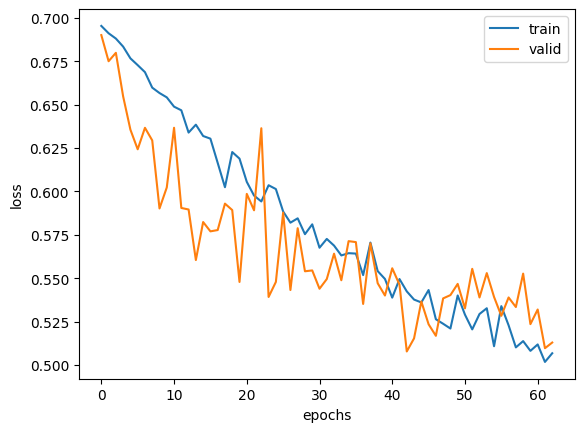

In [46]:
cnn_model.compile(
    loss='categorical_crossentropy',                          # 원-핫 레이블 다중 클래스 교차엔트로피 손실 함수[^1]
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),   # Adam 옵티마이저, 학습률 1e-4로 안정적·세밀한 업데이트[^2]
    metrics=['accuracy']                                      # 학습 중 정확도 모니터링
)

model_path   = './model/cnn_catndog.keras'
check_point  = ModelCheckpoint(
    model_path,
    save_best_only=True,      # 검증 손실이 최저인 모델만 저장하여 디스크 공간 절약[^3]
    monitor='val_loss',       # val_loss 기준으로 저장 여부 판단
    verbose=42
)
early_stop   = EarlyStopping(
    monitor='val_loss',      # 검증 손실 모니터링
    patience=20,             # 20 에포크 연속 개선 없으면 학습 중단
    restore_best_weights=True,# 에포크 종료 후 최적 가중치 복원[^4]
    verbose=42
)

cnn_history = cnn_model.fit(
    train_gen,                # 훈련 데이터 제너레이터
    epochs=100,               
    validation_data=valid_gen,# 검증 데이터 제너레이터
    callbacks=[early_stop, check_point]
)

plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step


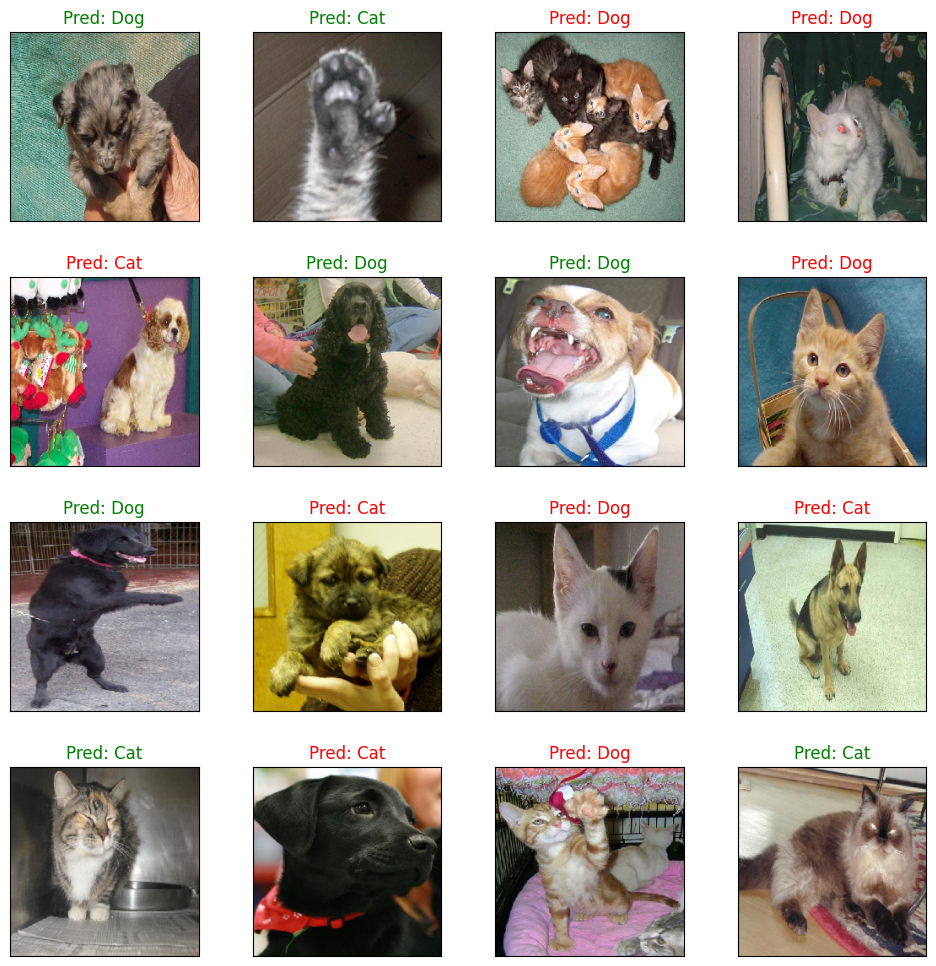


cnn_best_model 평가 결과: Loss: 0.7408, Accuracy: 0.4375


In [57]:
# (1) 최고의 모델 로드
cnn_best_model = load_model("./model/cnn_catndog.keras")                           # (1)

# (2) 클래스-인덱스 매핑 추출 및 클래스명 리스트 생성
class_indices = valid_gen.class_indices                                           # (2)
class_names   = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]  # (3)

# (3) 검증 데이터에서 한 배치(이미지 + 원-핫 레이블) 가져오기
validation_batch, label_batch = next(iter(valid_gen))                             # (4)

# (4) 예측 확률 계산 및 예측 인덱스로 변환
cnn_pred    = cnn_best_model.predict(validation_batch)                            # (5)
pred_values = np.argmax(cnn_pred, axis=1)                                        # (6)
true_values = np.argmax(label_batch, axis=1)                                     # (7)

# (5) 최대 16장을 4×4 그리드로 시각화 준비
fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)                                                   # (8)
num_images = min(16, validation_batch.shape[0])                                   # (9)

# (6) 각 이미지를 예측 레이블과 함께 표시 (정답일 땐 초록, 오답일 땐 빨강)
for i in range(num_images):
    ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i])
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color      = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)

plt.show()

# (7) 이 배치에 대해 손실과 정확도 평가 및 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)     # (10)
print(f"\ncnn_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

In [56]:
validation_batch.shape[0]

2

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음

# ResNet50

In [68]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2

In [64]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

In [65]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2,activation='softmax'))
res50_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [66]:
res50_model.compile(
    loss='categorical_crossentropy',                          # 원-핫 레이블 다중 클래스 교차엔트로피 손실 함수[^1]
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),   # Adam 옵티마이저, 학습률 1e-4로 안정적·세밀한 업데이트[^2]
    metrics=['accuracy']                                      # 학습 중 정확도 모니터링
)

model_path   = './model/res50_catndog.keras'
check_point  = ModelCheckpoint(
    model_path,
    save_best_only=True,      # 검증 손실이 최저인 모델만 저장하여 디스크 공간 절약[^3]
    monitor='val_loss',       # val_loss 기준으로 저장 여부 판단
    verbose=42
)
early_stop   = EarlyStopping(
    monitor='val_loss',      # 검증 손실 모니터링
    patience=20,             # 20 에포크 연속 개선 없으면 학습 중단
    restore_best_weights=True,# 에포크 종료 후 최적 가중치 복원[^4]
    verbose=42
)

res50_history = res50_model.fit(
    train_gen,                # 훈련 데이터 제너레이터
    epochs=100,               
    validation_data=valid_gen,# 검증 데이터 제너레이터
    callbacks=[early_stop, check_point]
)

plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()


Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4634 - loss: 0.7508
Epoch 1: val_loss improved from inf to 0.69636, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.4634 - loss: 0.7505 - val_accuracy: 0.5102 - val_loss: 0.6964
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.4952 - loss: 0.6945
Epoch 2: val_loss improved from 0.69636 to 0.69321, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 136s 787ms/step - accuracy: 0.4952 - loss: 0.6945 - val_accuracy: 0.4796 - val_loss: 0.6932
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.5293 - loss: 0.6931
Epoch 3: val_loss improved from 0.69321 to 0.69138, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 137s 982ms/step - accuracy: 0.5292 - loss: 0.6931 - val_accuracy: 0.5102 - val_loss: 0.6914
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4778 - loss: 0.6960
Epoch 

Epoch 24/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.5402 - loss: 0.6879
Epoch 24: val_loss did not improve from 0.67404
139/139 ━━━━━━━━━━━━━━━━━━━━ 118s 844ms/step - accuracy: 0.5402 - loss: 0.6879 - val_accuracy: 0.5408 - val_loss: 0.6743
Epoch 25/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.5523 - loss: 0.6872
Epoch 25: val_loss did not improve from 0.67404
139/139 ━━━━━━━━━━━━━━━━━━━━ 124s 897ms/step - accuracy: 0.5522 - loss: 0.6872 - val_accuracy: 0.5714 - val_loss: 0.6749
Epoch 26/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.5557 - loss: 0.6856
Epoch 26: val_loss did not improve from 0.67404
139/139 ━━━━━━━━━━━━━━━━━━━━ 125s 895ms/step - accuracy: 0.5557 - loss: 0.6856 - val_accuracy: 0.5714 - val_loss: 0.6751
Epoch 27/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.5298 - loss: 0.6899
Epoch 27: val_loss did not improve from 0.67404
139/139 ━━━━━━━━━━━━━━━━━━━━ 121s 868ms/step - accuracy: 0.5298 - loss: 0.6899 - val_

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


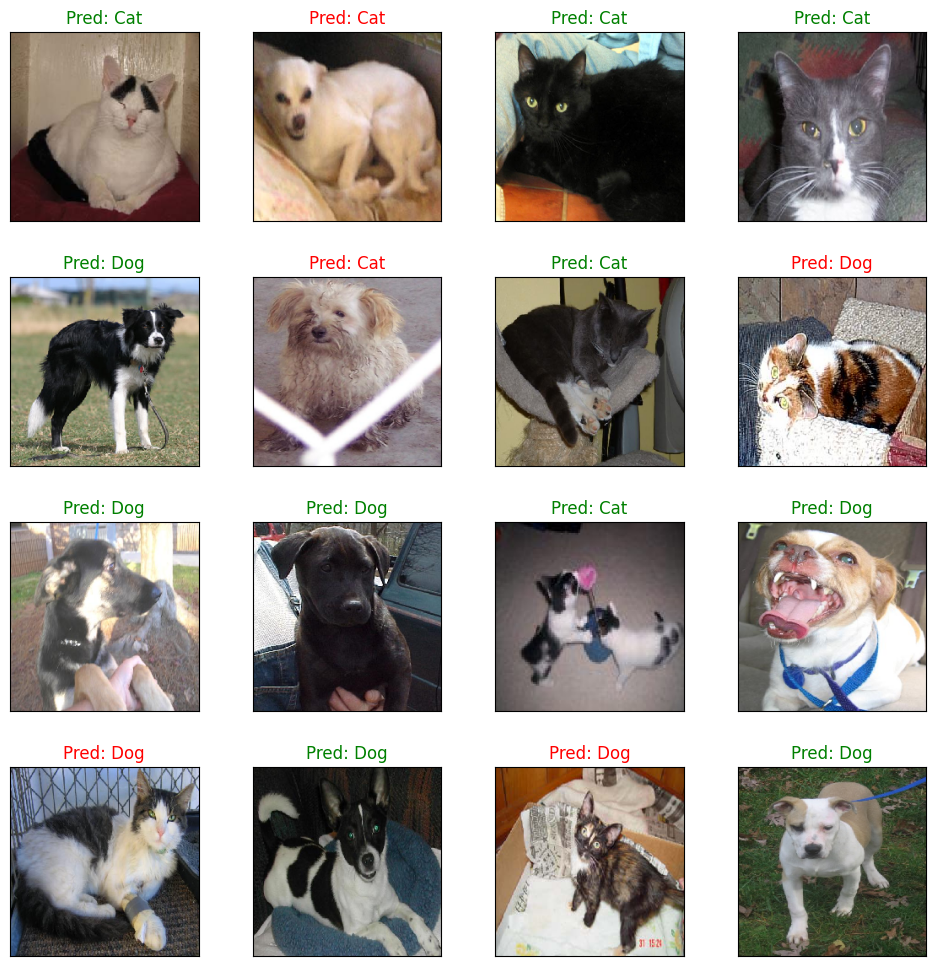


res50_best_model 평가 결과: Loss: 0.6787, Accuracy: 0.6875


In [72]:
# best 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

res50_pred = res50_best_model.predict(validation_batch)
pred_values = np.argmax(res50_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[pred_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color = color, fontsize = 12)
plt.show()

# loss와 accuracy 출력
loss, acc = res50_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres50_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# ResNet152V2

In [69]:
base_model2 = ResNet152V2(
    include_top = False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg')

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 41s 0us/step


In [70]:
base_model2.summary()

Model: "resnet152v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 58,331,648 (222.52 MB)

 Trainable params: 58,187,904 (221.97 MB)

 Non-trainable params: 143,744 (561.50 KB)

In [71]:
base_model2.trainable = False  # 가중치를 그대로 이용할 예정
res152v2_model = Sequential()
res152v2_model.add(base_model2)
res152v2_model.add(Dense(2, activation='softmax'))

In [73]:
res152v2_model.compile(
    loss='categorical_crossentropy',                          # 원-핫 레이블 다중 클래스 교차엔트로피 손실 함수[^1]
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),   # Adam 옵티마이저, 학습률 1e-4로 안정적·세밀한 업데이트[^2]
    metrics=['accuracy']                                      # 학습 중 정확도 모니터링
)

model_path   = './model/res152v2_catndog.keras'
check_point  = ModelCheckpoint(
    model_path,
    save_best_only=True,      # 검증 손실이 최저인 모델만 저장하여 디스크 공간 절약[^3]
    monitor='val_loss',       # val_loss 기준으로 저장 여부 판단
    verbose=42
)
early_stop   = EarlyStopping(
    monitor='val_loss',      # 검증 손실 모니터링
    patience=10,             # 20 에포크 연속 개선 없으면 학습 중단
    restore_best_weights=True,# 에포크 종료 후 최적 가중치 복원[^4]
    verbose=42
)

res152v2_history = res152v2_model.fit(
    train_gen,                # 훈련 데이터 제너레이터
    epochs=100,               
    validation_data=valid_gen,# 검증 데이터 제너레이터
    callbacks=[early_stop, check_point]
)

plt.plot(res152v2_history.history['loss'])
plt.plot(res152v2_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()

Epoch 1/100


2025-05-20 07:15:45.501135: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 676.06MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:15:53.456294: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.14GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:15:55.326388: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


 22/139 ━━━━━━━━━━━━━━━━━━━━ 3:31 2s/step - accuracy: 0.6535 - loss: 0.7944

2025-05-20 07:17:01.050410: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 659.56MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:17:07.252339: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.14GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:17:08.727998: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.33GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7302 - loss: 0.5902

2025-05-20 07:21:26.525511: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



Epoch 1: val_loss improved from inf to 0.11363, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.7307 - loss: 0.5891 - val_accuracy: 0.9592 - val_loss: 0.1136
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8959 - loss: 0.2647
Epoch 2: val_loss improved from 0.11363 to 0.07262, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.8960 - loss: 0.2644 - val_accuracy: 0.9694 - val_loss: 0.0726
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9261 - loss: 0.1783

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


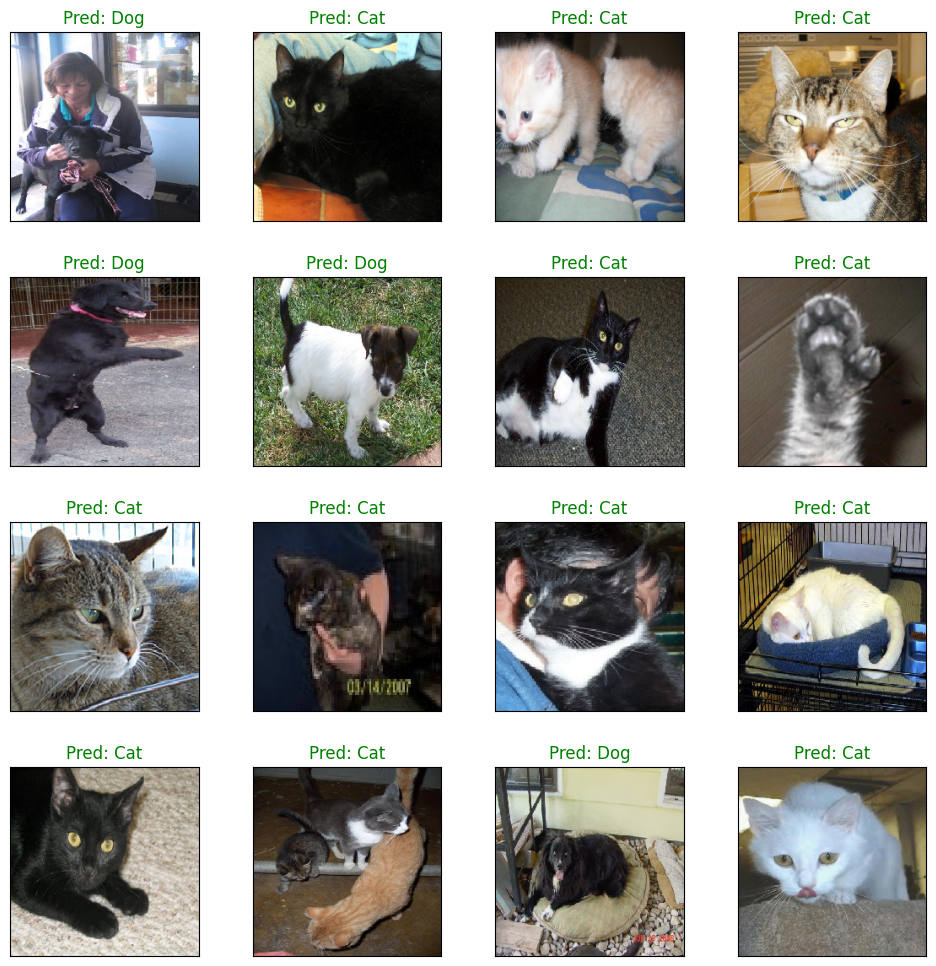


res152v2_best_model 평가 결과: Loss: 0.0810, Accuracy: 1.0000


In [74]:
# best 모델 로드
res152v2_best_model = load_model("./model/res152v2_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

res152v2_pred = res152v2_best_model.predict(validation_batch)
pred_values = np.argmax(res152v2_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[pred_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color = color, fontsize = 12)
plt.show()

# loss와 accuracy 출력
loss, acc = res152v2_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres152v2_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# convnextbase로 분석하기
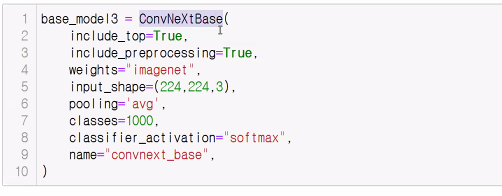

In [75]:
from tensorflow.keras.applications import ConvNeXtBase

In [77]:
base_model3 = ConvNeXtBase(
    include_top=True,
    include_preprocessing=True,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation='softmax',
    name='convnext_base')

355031056/355031056 ━━━━━━━━━━━━━━━━━━━━ 67s 0us/step


In [80]:
base_model3.trainable = False  # 가중치를 그대로 이용할 예정
ConvNeXtBase_model = Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation='softmax'))

In [81]:
ConvNeXtBase_model.compile(
    loss='categorical_crossentropy',                          # 원-핫 레이블 다중 클래스 교차엔트로피 손실 함수[^1]
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),   # Adam 옵티마이저, 학습률 1e-4로 안정적·세밀한 업데이트[^2]
    metrics=['accuracy']                                      # 학습 중 정확도 모니터링
)

model_path   = './model/ConvNeXtBase_catndog.keras'
check_point  = ModelCheckpoint(
    model_path,
    save_best_only=True,      # 검증 손실이 최저인 모델만 저장하여 디스크 공간 절약[^3]
    monitor='val_loss',       # val_loss 기준으로 저장 여부 판단
    verbose=42
)
early_stop   = EarlyStopping(
    monitor='val_loss',      # 검증 손실 모니터링
    patience=10,             # 20 에포크 연속 개선 없으면 학습 중단
    restore_best_weights=True,# 에포크 종료 후 최적 가중치 복원[^4]
    verbose=42
)

ConvNeXtBase_history = ConvNeXtBase_model.fit(
    train_gen,                # 훈련 데이터 제너레이터
    epochs=100,               
    validation_data=valid_gen,# 검증 데이터 제너레이터
    callbacks=[early_stop, check_point]
)

plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()

Epoch 1/100


2025-05-20 07:41:03.115975: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at xla_ops.cc:577 : RESOURCE_EXHAUSTED: Out of memory while trying to allocate 20971520 bytes.
2025-05-20 07:41:03.116183: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 20971520 bytes.
	 [[{{node StatefulPartitionedCall}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info. This isn't available when running in Eager mode.



ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/usr/lib/python3.11/runpy.py", line 198, in _run_module_as_main

  File "/usr/lib/python3.11/runpy.py", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/ipykernel_launcher.py", line 18, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 739, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 604, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 80, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 545, in dispatch_queue

  File "/usr/loc

In [83]:
# best 모델 로드
ConvNeXtBase_best_model = load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

ConvNeXtBase_pred = ConvNeXtBase_best_model.predict(validation_batch)
pred_values = np.argmax(res152v2_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[pred_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color = color, fontsize = 12)
plt.show()

# loss와 accuracy 출력
loss, acc = ConvNeXtBase_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nConvNeXtBase_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

ValueError: File not found: filepath=./model/ConvNeXtBase_catndog.keras. Please ensure the file is an accessible `.keras` zip file.